# Практическая работа №2  
## Визуализация многомерных данных. Лица Чернова

**Вариант 5 — зона F3_Z3_***  
**ФИО:** Бухарин М. А.

В ноутбуке выполнены:
- загрузка данных HVAC;
- выбор признаков только для зоны **F3_Z3**;
- статистический и корреляционный анализ;
- нормализация и стандартизация;
- выбор признаков для визуализации;
- построение схемы кодирования;
- построение календаря лиц Чернова по 14 дням;
- поиск аномальных дней и параметров, связанных с отклонениями.

## 1. Импорт библиотек и служебные функции

В работе используются `pandas`, `numpy`, `matplotlib`, `scikit-learn`.  
Сначала определим несколько вспомогательных функций:
- поиск столбца времени;
- извлечение признаков нужной зоны;
- приведение имен к удобному виду;
- построение глифа лица Чернова.

In [2]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from IPython.display import display

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.grid"] = False

def find_datetime_column(df: pd.DataFrame) -> str:
    """Возвращает имя столбца с датой/временем."""
    candidates = [
        "Date/Time", "DateTime", "Datetime", "timestamp", "Timestamp",
        "date_time", "date", "Date"
    ]
    for c in candidates:
        if c in df.columns:
            return c
    for c in df.columns:
        low = c.lower()
        if "time" in low or "date" in low:
            return c
    raise ValueError("Не найден столбец с датой/временем.")

def normalize_name_for_match(name: str) -> str:
    """Убирает все не-буквенно-цифровые символы для устойчивого поиска зоны."""
    return re.sub(r"[^a-zA-Z0-9]+", "", str(name)).lower()

def get_zone_columns(df: pd.DataFrame, zone_code: str = "F3_Z3") -> list[str]:
    """
    Возвращает столбцы нужной зоны.
    Поддерживаются варианты имён вида:
    - F3_Z3_...
    - F_3_Z_3: ...
    - любые другие вариации, если после очистки строка начинается с f3z3.
    """
    target = normalize_name_for_match(zone_code)
    cols = []
    for c in df.columns:
        if normalize_name_for_match(c).startswith(target):
            cols.append(c)
    return cols

def make_pretty_names(cols: list[str]) -> dict[str, str]:
    """
    Короткие человекочитаемые имена признаков.
    Если признаков больше, чем шаблонов, лишние будут названы P1, P2 ...
    """
    base = [
        "Температура", "Уставка нагрева", "Уставка охлаждения", "CO2",
        "Освещение", "Оборудование", "Расход воздуха", "Положение заслонки",
        "Нагрев", "Подача", "Возврат", "Влажность", "Давление", "Прочее"
    ]
    out = {}
    for i, c in enumerate(cols):
        label = base[i] if i < len(base) else f"P{i+1}"
        out[c] = label
    return out

def minmax_df(df: pd.DataFrame) -> pd.DataFrame:
    scaler = MinMaxScaler()
    arr = scaler.fit_transform(df.values)
    return pd.DataFrame(arr, index=df.index, columns=df.columns)

def standardize_df(df: pd.DataFrame) -> pd.DataFrame:
    scaler = StandardScaler()
    arr = scaler.fit_transform(df.values)
    return pd.DataFrame(arr, index=df.index, columns=df.columns)

print("Библиотеки и функции загружены.")

Библиотеки и функции загружены.


## 2. Загрузка данных и выделение зоны F3_Z3

Для варианта 5 анализируются только признаки зоны **F3_Z3**.  
Файл `bldg-MC2.csv` должен лежать рядом с ноутбуком либо путь к нему нужно указать вручную в переменной `DATA_PATH`.

In [3]:
# Путь к данным. При необходимости поменяйте на свой.
DATA_PATH = "bldg-MC2.csv"

candidate_paths = [
    Path(DATA_PATH),
    Path("/mnt/data") / DATA_PATH,
    Path("/mnt/data") / "bldg-MC2.csv",
    Path.cwd() / DATA_PATH,
]

csv_path = None
for p in candidate_paths:
    if p.exists():
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError(
        "Файл bldg-MC2.csv не найден. "
        "Положите его рядом с ноутбуком или укажите корректный путь в DATA_PATH."
    )

df = pd.read_csv(csv_path)
df.columns = df.columns.astype(str).str.strip()

dt_col = find_datetime_column(df)
df[dt_col] = pd.to_datetime(df[dt_col], errors="coerce")
df = df.dropna(subset=[dt_col]).copy()
df["Date"] = df[dt_col].dt.date
df["Hour"] = df[dt_col].dt.hour + df[dt_col].dt.minute / 60.0

zone_cols = get_zone_columns(df, "F3_Z3")

print(f"Файл: {csv_path}")
print(f"Столбец даты/времени: {dt_col}")
print(f"Найдено признаков зоны F3_Z3: {len(zone_cols)}")
for c in zone_cols:
    print(" -", c)

print(f"Период: {df[dt_col].min()} — {df[dt_col].max()}")
print(f"Количество строк: {len(df)}")
print(f"Количество уникальных дат: {df['Date'].nunique()}")

Файл: bldg-MC2.csv
Столбец даты/времени: Date/Time
Найдено признаков зоны F3_Z3: 10
 - F_3_Z_3: Lights Power
 - F_3_Z_3: Equipment Power
 - F_3_Z_3: Thermostat Temp
 - F_3_Z_3: Thermostat Heating Setpoint
 - F_3_Z_3: Thermostat Cooling Setpoint
 - F_3_Z_3 VAV REHEAT Damper Position
 - F_3_Z_3 REHEAT COIL Power
 - F_3_Z_3 RETURN OUTLET CO2 Concentration
 - F_3_Z_3 SUPPLY INLET Temperature
 - F_3_Z_3 SUPPLY INLET Mass Flow Rate
Период: 2016-05-31 00:00:00 — 2016-06-13 23:55:00
Количество строк: 4032
Количество уникальных дат: 14


## 3. Подготовка таблицы зоны и первичный просмотр

Здесь мы:
- оставляем только признаки зоны **F3_Z3**;
- переименовываем их в более компактный вид;
- смотрим первые строки данных.

In [4]:
if len(zone_cols) == 0:
    raise ValueError("Для зоны F3_Z3 не найдено ни одного признака. Проверьте формат названий столбцов в CSV.")

pretty_names = make_pretty_names(zone_cols)

df_zone = df[[dt_col, "Date", "Hour"] + zone_cols].copy()
df_zone = df_zone.rename(columns=pretty_names)

feature_cols = [pretty_names[c] for c in zone_cols]

display(df_zone.head(10))
print("Число признаков для анализа:", len(feature_cols))
print("Имена признаков:", feature_cols)

,Date/Time,Date,Hour,Температура,Уставка нагрева,Уставка охлаждения,CO2,Освещение,Оборудование,Расход воздуха,Положение заслонки,Нагрев,Подача
0,2016-05-31 00:00:00,2016-05-31,0.000000,0.0,105.8015,25.0259,15.6,26.7,0.2,0.0,496.8358,12.8008,0.0282
1,2016-05-31 00:05:00,2016-05-31,0.083333,0.0,105.8015,25.0340,15.6,26.7,0.2,0.0,496.3483,12.8008,0.0282
2,2016-05-31 00:10:00,2016-05-31,0.166667,0.0,105.8015,25.0416,15.6,26.7,0.2,0.0,495.8582,12.8000,0.0282
3,2016-05-31 00:15:00,2016-05-31,0.250000,0.0,105.8015,25.0489,15.6,26.7,0.2,0.0,495.3658,12.8007,0.0282
4,2016-05-31 00:20:00,2016-05-31,0.333333,0.0,105.8015,25.0558,15.6,26.7,0.2,0.0,494.8713,12.8004,0.0282
5,2016-05-31 00:25:00,2016-05-31,0.416667,0.0,105.8015,25.0623,15.6,26.7,0.2,0.0,494.3750,12.8012,0.0282
6,2016-05-31 00:30:00,2016-05-31,0.500000,0.0,105.8015,25.0684,15.6,26.7,0.2,0.0,493.8771,12.8012,0.0282
7,2016-05-31 00:35:00,2016-05-31,0.583333,0.0,105.8015,25.0741,15.6,26.7,0.2,0.0,493.3779,12.8012,0.0282
8,2016-05-31 00:40:00,2016-05-31,0.666667,0.0,105.8015,25.0794,15.6,26.7,0.2,0.0,492.8776,12.8011,0.0282
9,2016-05-31 00:45:00,2016-05-31,0.750000,0.0,105.8015,25.0842,15.6,26.7,0.2,0.0,492.3765,12.8011,0.0282


Число признаков для анализа: 10
Имена признаков: ['Температура', 'Уставка нагрева', 'Уставка охлаждения', 'CO2', 'Освещение', 'Оборудование', 'Расход воздуха', 'Положение заслонки', 'Нагрев', 'Подача']


## 4. Статистический анализ признаков

Для выбора признаков под глиф важно понять:
- разброс значений;
- наличие почти постоянных параметров;
- дублирование признаков;
- основные корреляции между ними.

Рассчитаем базовые статистики: среднее, стандартное отклонение, дисперсию, минимум, максимум, медиану и коэффициент вариации.

In [5]:
stats = pd.DataFrame(index=feature_cols)
stats["mean"] = df_zone[feature_cols].mean()
stats["std"] = df_zone[feature_cols].std()
stats["var"] = df_zone[feature_cols].var()
stats["min"] = df_zone[feature_cols].min()
stats["max"] = df_zone[feature_cols].max()
stats["median"] = df_zone[feature_cols].median()
stats["cv"] = stats["std"] / stats["mean"].replace(0, np.nan)

stats = stats.sort_values("std", ascending=False)

print("Статистики признаков зоны F3_Z3:")
display(stats.round(4))

Статистики признаков зоны F3_Z3:


,mean,std,var,min,max,median,cv
Расход воздуха,380.3476,519.6281,270013.3818,0.0000,3447.9638,0.0000,1.3662
Температура,193.8046,330.0452,108929.8446,0.0000,755.7254,0.0000,1.7030
Положение заслонки,614.3614,263.1741,69260.5899,401.4980,1580.8617,505.7522,0.4284
Уставка нагрева,214.3321,184.8253,34160.3954,105.8015,529.0077,105.8015,0.8623
Нагрев,15.6435,4.1413,17.1506,12.2806,39.9983,12.8013,0.2647
CO2,21.0281,4.0422,16.3394,12.6000,26.6700,21.0000,0.1922
Освещение,24.1299,3.2227,10.3855,15.5600,29.7000,24.0000,0.1336
Уставка охлаждения,24.4885,1.4530,2.1113,20.8313,30.6038,24.0001,0.0593
Оборудование,0.7191,0.3468,0.1203,0.2000,1.0000,0.9702,0.4823
Подача,0.1015,0.0487,0.0024,0.0282,0.1409,0.1368,0.4799


### Интерпретация статистик

Для визуализации лучше оставить признаки:
- с заметной изменчивостью;
- не являющиеся дубликатами;
- отражающие разные аспекты работы системы.

Признаки с очень маленькой дисперсией обычно не дают полезного сигнала в глифе и могут быть исключены.

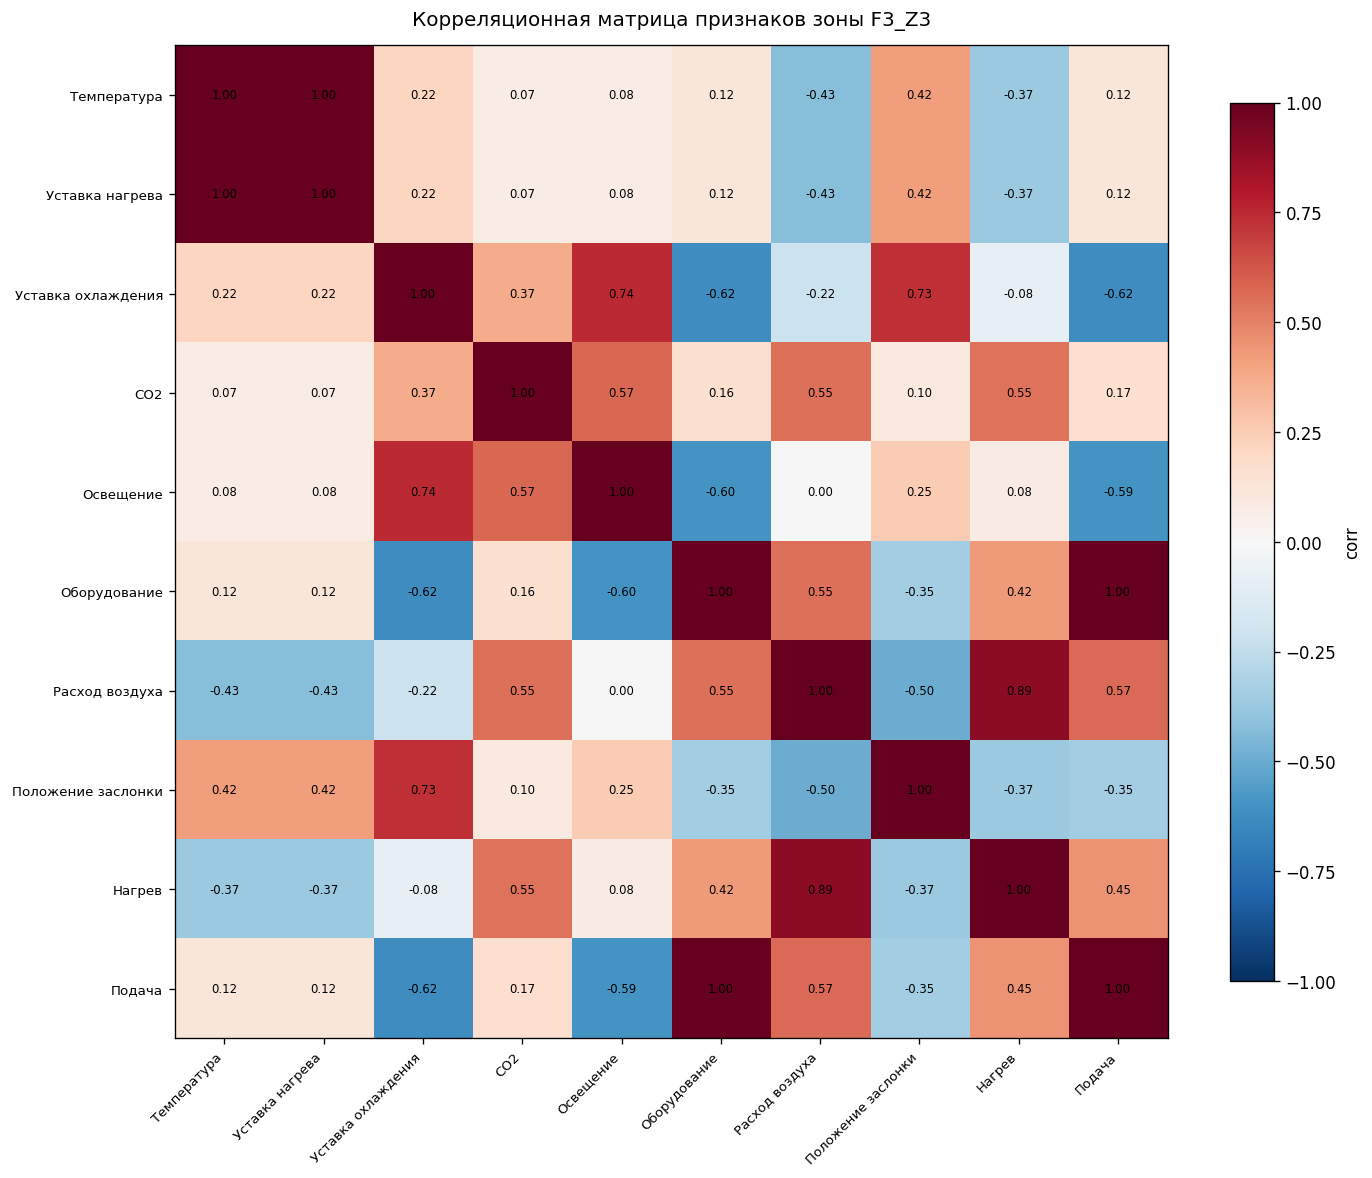

In [6]:
# Матрица корреляции по исходным измерениям
corr = df_zone[feature_cols].corr()

fig, ax = plt.subplots(figsize=(min(12, 1.1 * len(feature_cols) + 3), min(10, 1.0 * len(feature_cols) + 3)))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(feature_cols, fontsize=8)
ax.set_title("Корреляционная матрица признаков зоны F3_Z3", pad=12)

for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=7)

cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("corr")
plt.tight_layout()
plt.show()

In [8]:
# Поиск сильно коррелированных пар для понимания избыточности признаков
threshold = 0.85
pairs = []
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        v = corr.iloc[i, j]
        if abs(v) >= threshold:
            pairs.append((feature_cols[i], feature_cols[j], float(v)))

pairs_df = pd.DataFrame(pairs, columns=["feature_1", "feature_2", "corr"]).sort_values("corr", key=lambda s: s.abs(), ascending=False)

if len(pairs_df) == 0:
    print(f"Пар с |corr| >= {threshold} не найдено.")
else:
    print(f"Пары с |corr| >= {threshold}:")
    display(pairs_df)

Пары с |corr| >= 0.85:


,feature_1,feature_2,corr
0,Температура,Уставка нагрева,1.000000
1,Оборудование,Подача,0.996970
2,Расход воздуха,Нагрев,0.893862


## 5. Переход к дневным наборам данных

По условию работы исходный ряд нужно разбить на **14 дневных наборов**.  
Для каждого дня берём средние значения признаков. Это удобно для календарной визуализации: каждый день превращается в одно лицо.

In [7]:
daily_raw = df_zone.groupby("Date")[feature_cols].mean().sort_index()

print("Дневная таблица:")
display(daily_raw.round(4))

print(f"Количество дней: {len(daily_raw)}")

Дневная таблица:


,Температура,Уставка нагрева,Уставка охлаждения,CO2,Освещение,Оборудование,Расход воздуха,Положение заслонки,Нагрев,Подача
Date,,,,,,,,,,
2016-05-31,272.9008,258.6260,24.3700,19.2500,24.8958,0.5210,0.0000,577.2992,12.8007,0.0734
2016-06-01,220.4199,229.2366,24.3496,19.2500,24.8958,0.4808,0.0000,583.1449,12.8008,0.0677
2016-06-02,280.7730,263.0344,24.3921,19.2500,24.8958,0.5355,0.0000,589.3858,12.8007,0.0754
2016-06-03,283.3970,264.5038,24.3606,20.4208,24.6802,0.7060,218.4025,583.5641,14.3233,0.0995
2016-06-04,0.0000,105.8015,24.0000,24.0000,24.0000,1.0000,1058.0009,435.5853,20.1740,0.1409
2016-06-05,0.0000,105.8015,24.0000,24.0000,24.0000,1.0000,1057.0643,404.0147,20.1681,0.1409
2016-06-06,278.1489,261.5649,24.1010,21.0292,24.3240,0.6873,235.8271,552.6122,14.4428,0.0968
2016-06-07,270.2768,257.1565,26.0322,21.4042,24.4362,0.5153,83.4681,974.0022,15.0646,0.0744
2016-06-08,283.3970,264.5038,26.4808,21.3938,24.3975,0.5163,57.0967,1163.7234,14.2082,0.0736


Количество дней: 14


## 6. Нормализация и стандартизация

Для корректного сравнения признаков с разными масштабами используем:
- **Min-Max нормализацию** — для построения глифов;
- **стандартизацию** — для расчёта аномалий и сравнения отклонений.

Такой подход позволяет:
- привести параметры к единому масштабу;
- сделать глифы сопоставимыми;
- выделять необычные дни по суммарному отклонению.

In [8]:
daily_minmax = minmax_df(daily_raw)
daily_std = standardize_df(daily_raw)

print("Min-Max нормализованные дневные значения:")
display(daily_minmax.round(3))

print("Стандартизованные дневные значения:")
display(daily_std.round(3))

Min-Max нормализованные дневные значения:


,Температура,Уставка нагрева,Уставка охлаждения,CO2,Освещение,Оборудование,Расход воздуха,Положение заслонки,Нагрев,Подача
Date,,,,,,,,,,
2016-05-31,0.954,0.954,0.149,0.475,1.000,0.077,0.000,0.228,0.000,0.077
2016-06-01,0.771,0.771,0.141,0.475,1.000,0.000,0.000,0.236,0.000,0.000
2016-06-02,0.982,0.982,0.158,0.475,1.000,0.105,0.000,0.244,0.000,0.105
2016-06-03,0.991,0.991,0.145,0.605,0.953,0.434,0.196,0.236,0.197,0.434
2016-06-04,0.000,0.000,0.000,1.000,0.806,1.000,0.951,0.042,0.951,1.000
2016-06-05,0.000,0.000,0.000,1.000,0.806,1.000,0.950,0.000,0.951,1.000
2016-06-06,0.972,0.972,0.041,0.672,0.876,0.398,0.212,0.196,0.212,0.398
2016-06-07,0.945,0.945,0.819,0.713,0.900,0.066,0.075,0.750,0.292,0.091
2016-06-08,0.991,0.991,1.000,0.712,0.892,0.068,0.051,1.000,0.182,0.081


Стандартизованные дневные значения:


,Температура,Уставка нагрева,Уставка охлаждения,CO2,Освещение,Оборудование,Расход воздуха,Положение заслонки,Нагрев,Подача
Date,,,,,,,,,,
2016-05-31,0.640,0.640,-0.159,-0.731,0.687,-1.016,-0.853,-0.177,-0.944,-1.031
2016-06-01,0.215,0.215,-0.187,-0.731,0.687,-1.222,-0.853,-0.149,-0.944,-1.238
2016-06-02,0.704,0.704,-0.130,-0.731,0.687,-0.942,-0.853,-0.119,-0.944,-0.956
2016-06-03,0.725,0.725,-0.172,-0.250,0.493,-0.067,-0.363,-0.147,-0.438,-0.075
2016-06-04,-1.568,-1.568,-0.657,1.222,-0.116,1.441,1.520,-0.855,1.504,1.444
2016-06-05,-1.568,-1.568,-0.657,1.222,-0.116,1.441,1.518,-1.006,1.503,1.444
2016-06-06,0.683,0.683,-0.521,0.000,0.174,-0.163,-0.324,-0.295,-0.399,-0.171
2016-06-07,0.619,0.619,2.077,0.155,0.275,-1.045,-0.666,1.720,-0.192,-0.993
2016-06-08,0.725,0.725,2.681,0.150,0.240,-1.040,-0.725,2.627,-0.477,-1.022


In [9]:
# Аномальный скор для каждого дня:
# суммарное отклонение от медианы в стандартизованном пространстве
robust_center = daily_raw.median(axis=0)

robust_scale = (daily_raw - robust_center).abs().mean(axis=0)
std_vals = daily_raw.std(axis=0)
std_vals[std_vals == 0] = 1.0

robust_scale[robust_scale == 0] = std_vals[robust_scale == 0]
robust_scale[robust_scale == 0] = 1.0

robust_z = (daily_raw - robust_center) / robust_scale
anomaly_score = robust_z.abs().mean(axis=1)

q1, q3 = anomaly_score.quantile([0.25, 0.75])
iqr = q3 - q1
threshold_score = q3 + 1.5 * iqr

anomaly_days = anomaly_score[anomaly_score > threshold_score].index.tolist()

print("Скор аномальности по дням:")
display(anomaly_score.sort_values(ascending=False).to_frame("anomaly_score").round(4))

print(f"Порог аномальности: {threshold_score:.4f}")
print("Аномальные дни:", anomaly_days if anomaly_days else "не выявлены по выбранному порогу")

Скор аномальности по дням:


,anomaly_score
Date,
2016-06-12,1.9967
2016-06-05,1.9664
2016-06-04,1.9432
2016-06-11,1.9400
2016-06-09,1.3907
2016-06-08,1.2860
2016-06-07,1.0310
2016-06-01,0.7258
2016-06-02,0.5745


Порог аномальности: 4.0990
Аномальные дни: не выявлены по выбранному порогу


## 7. Выбор признаков для глифа

Для глифа не нужно отображать все признаки одинаково. Лучше оставить компактный набор, который:
- имеет хорошую изменчивость;
- не дублирует другие признаки;
- отражает важные аспекты работы системы.

Стратегия отбора:
1. убрать почти константные признаки;
2. убрать явные дубликаты по корреляции;
3. оставить признаки с максимальной вариативностью.

Далее первые признаки будут использованы для формы лица, глаз, бровей, рта и дополнительных деталей.

In [10]:
# Отбор признаков по стандартному отклонению с учётом корреляционной избыточности
std_order = stats["std"].sort_values(ascending=False).index.tolist()

selected = []
for col in std_order:
    if stats.loc[col, "std"] == 0 or pd.isna(stats.loc[col, "std"]):
        continue
    redundant = False
    for s in selected:
        if abs(corr.loc[col, s]) >= 0.90:
            redundant = True
            break
    if not redundant:
        selected.append(col)
    if len(selected) == min(8, len(feature_cols)):
        break

# если признаков мало, дополняем самыми вариативными
for col in std_order:
    if len(selected) == min(8, len(feature_cols)):
        break
    if col not in selected:
        selected.append(col)

print("Отобранные признаки для визуализации:")
for i, c in enumerate(selected, 1):
    print(f"{i}. {c}  (std={stats.loc[c, 'std']:.4f})")

selected_daily = daily_minmax[selected].copy()
display(selected_daily.round(3))

Отобранные признаки для визуализации:
1. Расход воздуха  (std=519.6281)
2. Температура  (std=330.0452)
3. Положение заслонки  (std=263.1741)
4. Нагрев  (std=4.1413)
5. CO2  (std=4.0422)
6. Освещение  (std=3.2227)
7. Уставка охлаждения  (std=1.4530)
8. Оборудование  (std=0.3468)


,Расход воздуха,Температура,Положение заслонки,Нагрев,CO2,Освещение,Уставка охлаждения,Оборудование
Date,,,,,,,,
2016-05-31,0.000,0.954,0.228,0.000,0.475,1.000,0.149,0.077
2016-06-01,0.000,0.771,0.236,0.000,0.475,1.000,0.141,0.000
2016-06-02,0.000,0.982,0.244,0.000,0.475,1.000,0.158,0.105
2016-06-03,0.196,0.991,0.236,0.197,0.605,0.953,0.145,0.434
2016-06-04,0.951,0.000,0.042,0.951,1.000,0.806,0.000,1.000
2016-06-05,0.950,0.000,0.000,0.951,1.000,0.806,0.000,1.000
2016-06-06,0.212,0.972,0.196,0.212,0.672,0.876,0.041,0.398
2016-06-07,0.075,0.945,0.750,0.292,0.713,0.900,0.819,0.066
2016-06-08,0.051,0.991,1.000,0.182,0.712,0.892,1.000,0.068


## 8. Схема кодирования визуализации

Для лица Чернова используем следующие визуальные переменные:

- **цвет лица** — один из наиболее интерпретируемых параметров состояния системы;
- **размер глаз** — реакция на резкие изменения;
- **зрачки** — более тонкое кодирование одного из ключевых параметров;
- **наклон бровей** — хорошо заметный индикатор отклонений;
- **кривизна рта** — показывает «настроение» системы;
- **ширина/высота лица** — общий масштаб состояния;
- **волосы** — дополнительный параметр, удобно кодировать уставки или мощность;
- **нос** — ещё один вспомогательный параметр для различения дней.

Такое кодирование удобно тем, что человек очень быстро замечает:
- асимметрию;
- «печальные» или «удивлённые» лица;
- резкие изменения формы от дня к дню.

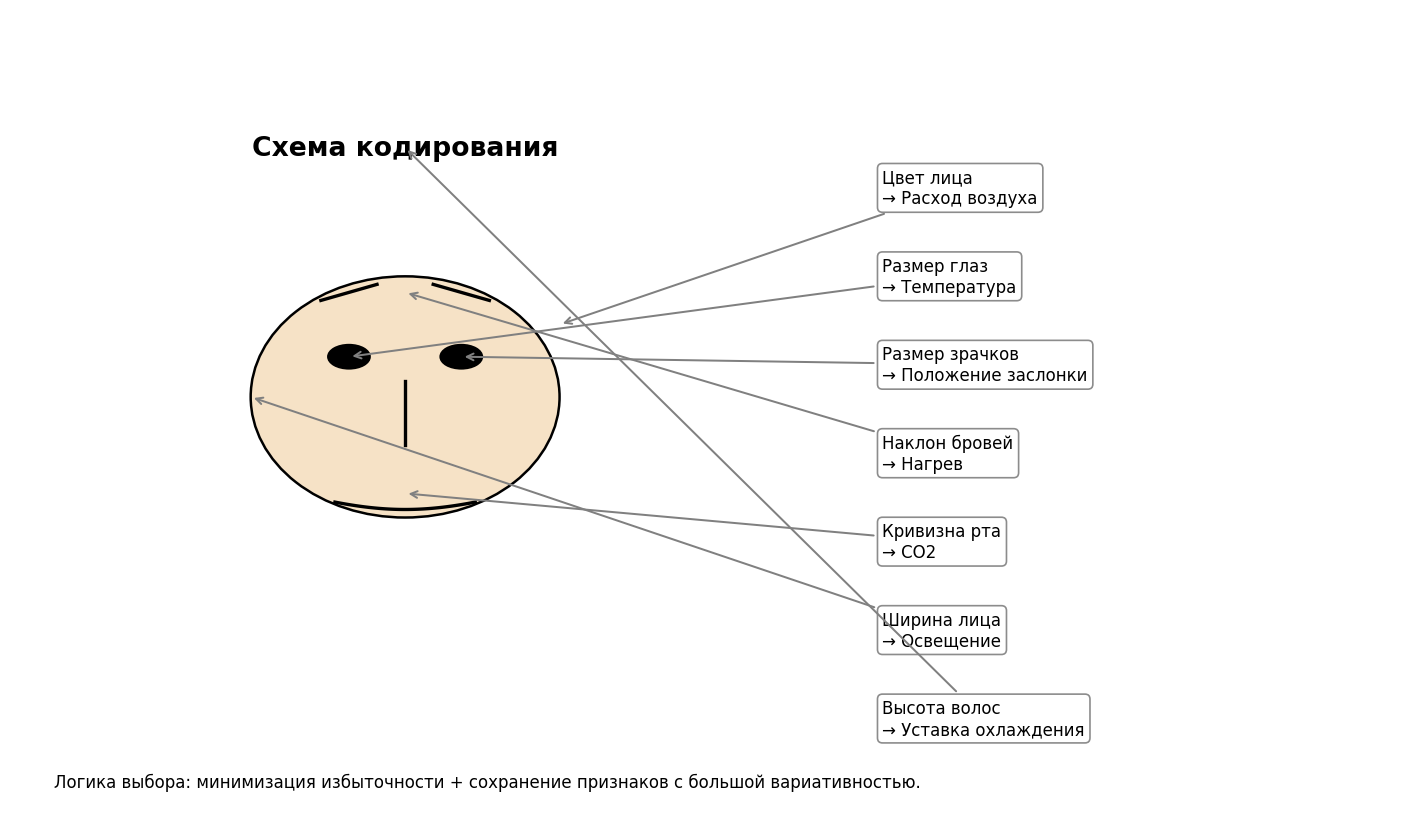

Схема сохранена в: chernoff_scheme.png


In [12]:
def draw_encoding_scheme(selected_features: list[str], save_path: str | None = None):
    # Схема кодирования признаков по элементам лица
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    # лицо
    face = patches.Ellipse((0.28, 0.52), 0.22, 0.30, facecolor="#f6e2c6", edgecolor="black", linewidth=1.5)
    ax.add_patch(face)
    ax.text(0.28, 0.83, "Схема кодирования", ha="center", va="center", fontsize=16, fontweight="bold")

    # элементы лица
    ax.add_patch(patches.Circle((0.24, 0.57), 0.015, color="black"))
    ax.add_patch(patches.Circle((0.32, 0.57), 0.015, color="black"))
    ax.plot([0.22, 0.26], [0.64, 0.66], color="black", lw=2)
    ax.plot([0.30, 0.34], [0.66, 0.64], color="black", lw=2)
    ax.plot([0.28, 0.28], [0.54, 0.46], color="black", lw=2)
    mouth_x = np.linspace(0.23, 0.33, 100)
    mouth_y = 0.40 - 0.02 * np.cos((mouth_x - 0.28) * 20)
    ax.plot(mouth_x, mouth_y, color="black", lw=2)

    mapping = [
        ("Цвет лица", selected_features[0] if len(selected_features) > 0 else "P1", (0.62, 0.78), (0.39, 0.61)),
        ("Размер глаз", selected_features[1] if len(selected_features) > 1 else "P2", (0.62, 0.67), (0.24, 0.57)),
        ("Размер зрачков", selected_features[2] if len(selected_features) > 2 else "P3", (0.62, 0.56), (0.32, 0.57)),
        ("Наклон бровей", selected_features[3] if len(selected_features) > 3 else "P4", (0.62, 0.45), (0.28, 0.65)),
        ("Кривизна рта", selected_features[4] if len(selected_features) > 4 else "P5", (0.62, 0.34), (0.28, 0.40)),
        ("Ширина лица", selected_features[5] if len(selected_features) > 5 else "P6", (0.62, 0.23), (0.17, 0.52)),
        ("Высота волос", selected_features[6] if len(selected_features) > 6 else "P7", (0.62, 0.12), (0.28, 0.83)),
    ]

    for label, feat, text_xy, target_xy in mapping:
        ax.annotate(
            f"{label}\n→ {feat}",
            xy=target_xy,
            xycoords="data",
            xytext=text_xy,
            textcoords="data",
            ha="left",
            va="center",
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),
            arrowprops=dict(arrowstyle="->", lw=1.2, color="gray")
        )

    ax.text(
        0.03, 0.03,
        "Логика выбора: минимизация избыточности + сохранение признаков с большой вариативностью.",
        fontsize=10, ha="left", va="bottom"
    )

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=160)
    plt.show()

scheme_path = "chernoff_scheme.png"
draw_encoding_scheme(selected, save_path=scheme_path)
print("Схема сохранена в:", scheme_path)

## 9. Реализация лица Чернова

Ниже функция строит одно лицо по набору нормализованных признаков.  
Диапазон значений предполагается от 0 до 1.

Идея:
- 0 соответствует минимальному значению признака;
- 1 соответствует максимальному;
- промежуточные значения изменяют форму, цвет и выражение лица.

In [13]:
def clip01(x):
    return float(np.clip(x, 0.0, 1.0))

def blend(c1, c2, t):
    c1 = np.array(c1)
    c2 = np.array(c2)
    return tuple((1 - t) * c1 + t * c2)

def draw_chernoff_face(ax, values, title="", anomaly=False):
    # Рисует лицо Чернова по значениям [0,1].
    vals = list(values)
    while len(vals) < 8:
        vals.append(0.5)
    vals = [clip01(v) for v in vals[:8]]

    face_color = vals[0]
    eye_size = vals[1]
    pupil_size = vals[2]
    brow_tilt = vals[3]
    mouth_curve = vals[4]
    face_width = vals[5]
    hair_height = vals[6]
    nose_length = vals[7]

    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.7, 1.8)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_facecolor("#f3f6fa" if not anomaly else "#fff3f3")

    # оттенок лица: холодный -> нейтральный -> тёплый
    skin = blend((0.84, 0.92, 1.00), (1.00, 0.86, 0.79), face_color)
    skin = blend(skin, (0.98, 0.77, 0.65), 0.25 * face_color)

    # форма лица
    w = 1.0 + 0.35 * (face_width - 0.5) * 2
    h = 1.25
    face = patches.Ellipse((0, 0.05), width=w, height=h, facecolor=skin, edgecolor="black", linewidth=1.4)
    ax.add_patch(face)

    # волосы
    hair_color = blend((0.15, 0.10, 0.05), (0.55, 0.35, 0.15), hair_height)
    hair = patches.Ellipse(
        (0, 0.67 + 0.1 * hair_height),
        width=w * 1.02,
        height=0.55 + 0.35 * hair_height,
        facecolor=hair_color,
        edgecolor="black",
        linewidth=1.0
    )
    ax.add_patch(hair)

    # глаза
    eye_y = 0.25
    eye_x = 0.28
    eye_w = 0.18 + 0.14 * eye_size
    eye_h = 0.12 + 0.10 * eye_size
    left_eye = patches.Ellipse((-eye_x, eye_y), eye_w, eye_h, facecolor="white", edgecolor="black", linewidth=1.0)
    right_eye = patches.Ellipse((eye_x, eye_y), eye_w, eye_h, facecolor="white", edgecolor="black", linewidth=1.0)
    ax.add_patch(left_eye)
    ax.add_patch(right_eye)

    pupil_r = 0.015 + 0.045 * pupil_size
    ax.add_patch(patches.Circle((-eye_x, eye_y), pupil_r, color="black"))
    ax.add_patch(patches.Circle((eye_x, eye_y), pupil_r, color="black"))

    # брови
    brow_y = 0.43
    brow_len = 0.20 + 0.16 * brow_tilt
    brow_delta = 0.08 * (brow_tilt - 0.5) * 2
    ax.plot([-eye_x - brow_len/2, -eye_x + brow_len/2], [brow_y + brow_delta, brow_y - brow_delta], lw=2.2, color="black")
    ax.plot([ eye_x - brow_len/2,  eye_x + brow_len/2], [brow_y - brow_delta, brow_y + brow_delta], lw=2.2, color="black")

    # нос
    nose_top = 0.13
    nose_bottom = nose_top - (0.18 + 0.22 * nose_length)
    ax.plot([0, 0], [nose_top, nose_bottom], color="black", lw=1.8)
    ax.plot([-0.05, 0.05], [nose_bottom, nose_bottom - 0.04], color="black", lw=1.4)

    # рот
    x = np.linspace(-0.30, 0.30, 120)
    curve = (mouth_curve - 0.5) * 0.9
    y = -0.42 + curve * (1 - (x / 0.30) ** 2)
    ax.plot(x, y, color="black", lw=2.2)

    # щёки
    ax.add_patch(patches.Circle((-0.42, -0.05), 0.03 + 0.04 * (1 - face_color), facecolor="#ffcad4", edgecolor="none", alpha=0.35))
    ax.add_patch(patches.Circle(( 0.42, -0.05), 0.03 + 0.04 * (1 - face_color), facecolor="#ffcad4", edgecolor="none", alpha=0.35))

    # рамка и заголовок
    if anomaly:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(2.0)
            spine.set_edgecolor("#b00020")
    ax.set_title(title, fontsize=10, pad=4, color=("#b00020" if anomaly else "black"))

def prepare_face_matrix(daily_df: pd.DataFrame, feature_list: list[str], n_features: int = 8) -> pd.DataFrame:
    # Преобразует дневную таблицу в матрицу для глифов.
    X = daily_df[feature_list].copy()
    X = minmax_df(X)
    if X.shape[1] < n_features:
        for i in range(X.shape[1], n_features):
            X[f"pad_{i+1}"] = 0.5
    elif X.shape[1] > n_features:
        X = X.iloc[:, :n_features]
    return X

face_matrix = prepare_face_matrix(daily_raw, selected, n_features=8)
display(face_matrix.round(3))

,Расход воздуха,Температура,Положение заслонки,Нагрев,CO2,Освещение,Уставка охлаждения,Оборудование
Date,,,,,,,,
2016-05-31,0.000,0.954,0.228,0.000,0.475,1.000,0.149,0.077
2016-06-01,0.000,0.771,0.236,0.000,0.475,1.000,0.141,0.000
2016-06-02,0.000,0.982,0.244,0.000,0.475,1.000,0.158,0.105
2016-06-03,0.196,0.991,0.236,0.197,0.605,0.953,0.145,0.434
2016-06-04,0.951,0.000,0.042,0.951,1.000,0.806,0.000,1.000
2016-06-05,0.950,0.000,0.000,0.951,1.000,0.806,0.000,1.000
2016-06-06,0.212,0.972,0.196,0.212,0.672,0.876,0.041,0.398
2016-06-07,0.075,0.945,0.750,0.292,0.713,0.900,0.819,0.066
2016-06-08,0.051,0.991,1.000,0.182,0.712,0.892,1.000,0.068


## 10. Календарйная визуализация лиц Чернова

Каждый день отображается отдельным глифом.  
Аномальные дни выделяются красной рамкой, а подпись содержит значок `⚠`.

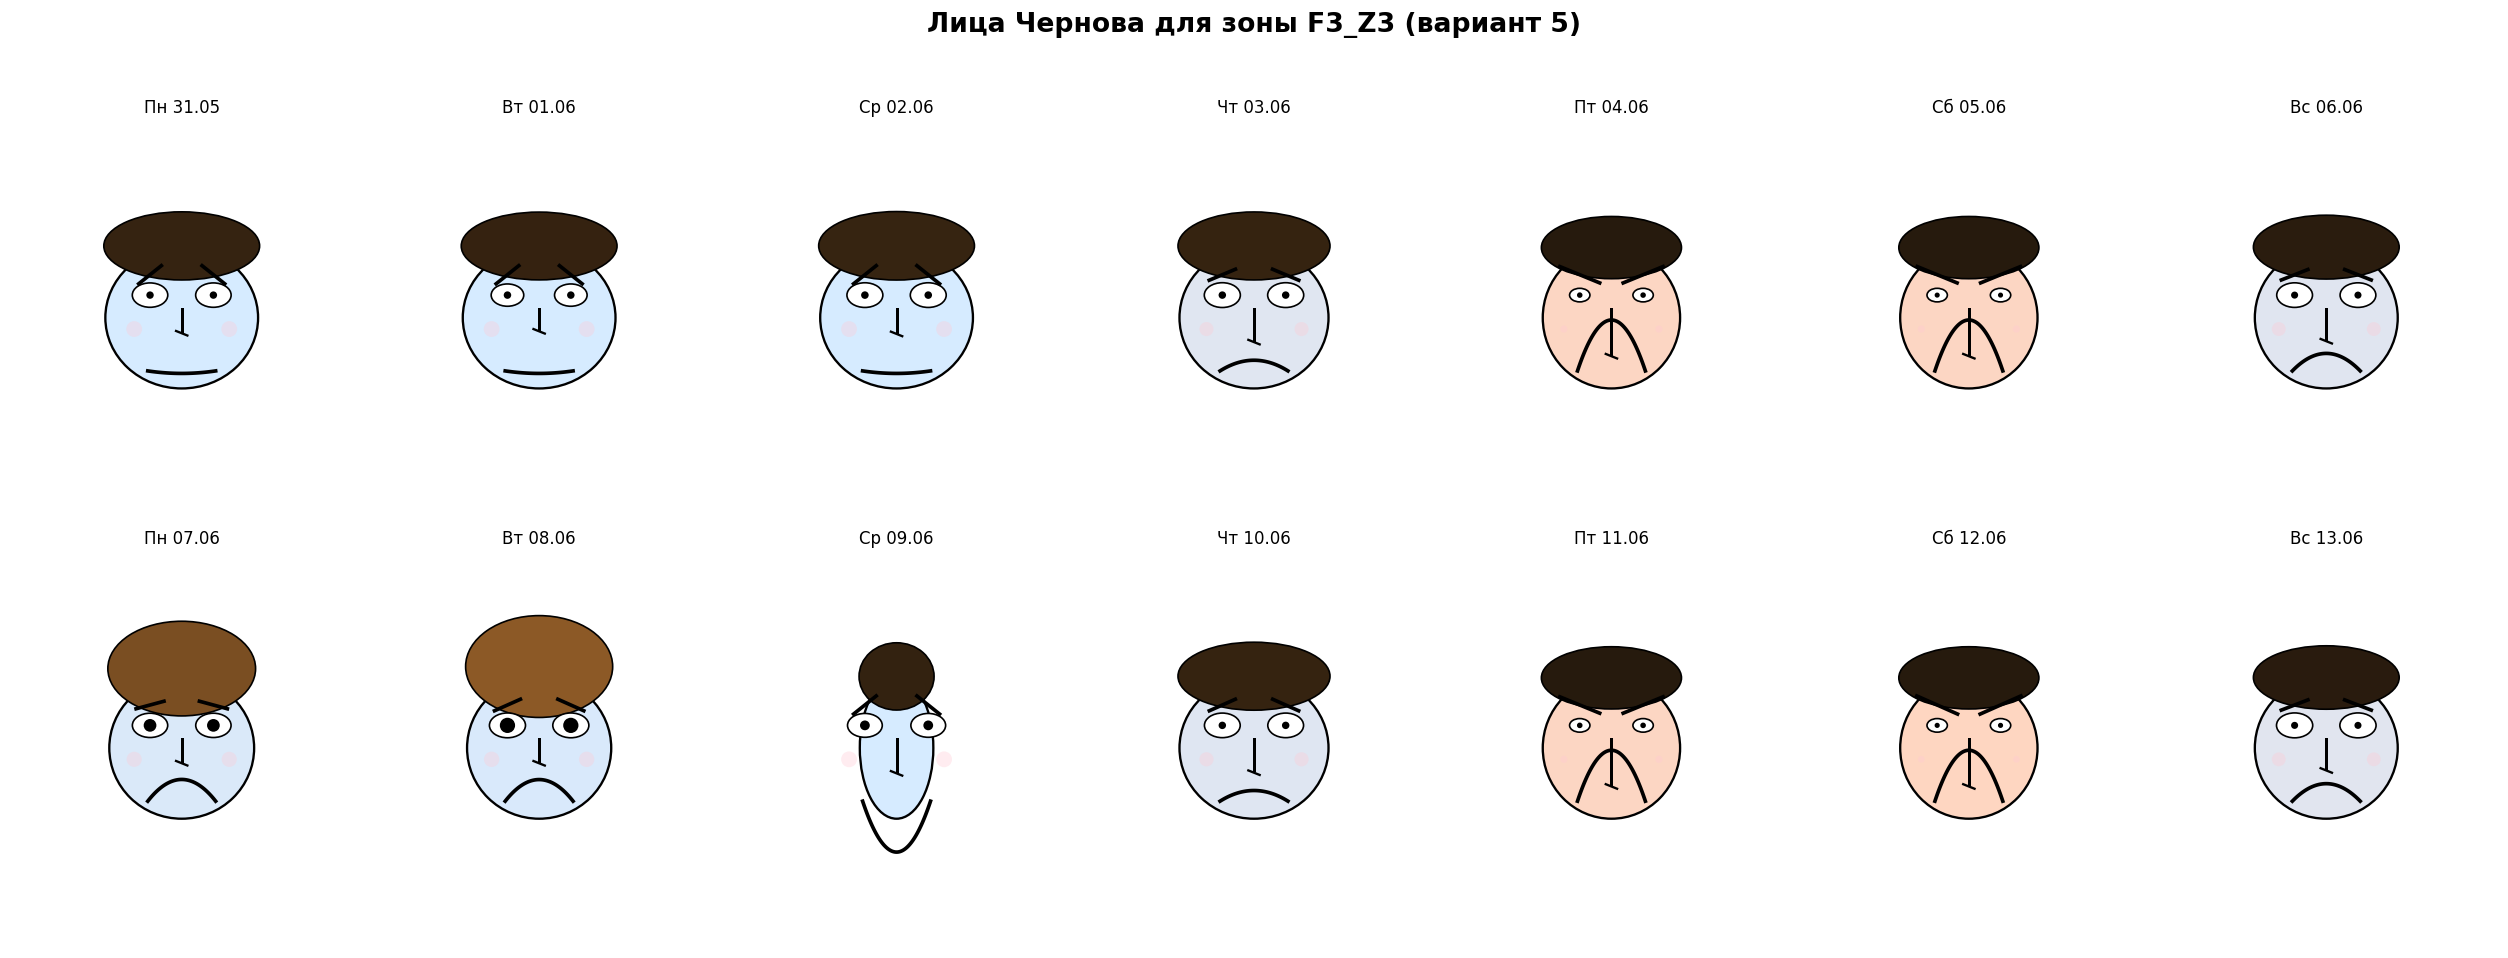

Календарь сохранён в: chernoff_calendar.png


In [15]:
days = list(face_matrix.index)
n_days = len(days)

rows, cols = 2, 7
fig, axes = plt.subplots(rows, cols, figsize=(21, 8))
fig.suptitle("Лица Чернова для зоны F3_Z3 (вариант 5)", fontsize=16, fontweight="bold", y=1.02)

day_labels = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]

for i, day in enumerate(days):
    ax = axes[i // cols, i % cols]
    vals = face_matrix.loc[day].values
    is_anomaly = day in anomaly_days
    date_text = pd.Timestamp(day).strftime("%d.%m")
    title = f"{day_labels[i % 7]} {date_text}" + (" ⚠" if is_anomaly else "")
    draw_chernoff_face(ax, vals, title=title, anomaly=is_anomaly)

for j in range(n_days, rows * cols):
    ax = axes[j // cols, j % cols]
    ax.axis("off")

plt.tight_layout()
calendar_path = "chernoff_calendar.png"
fig.savefig(calendar_path, bbox_inches="tight", dpi=160)
plt.show()

print("Календарь сохранён в:", calendar_path)

## 11. Поиск параметров, связанных с аномалиями

Чтобы ответить на вопрос о том, какие параметры связаны с отклонениями, сравним аномальные дни с общей дневной картиной:
- посмотрим, какие признаки сильнее всего отклоняются;
- оценим их вклад в суммарный аномальный скор;
- выделим параметры, наиболее часто входящие в топ по модулю стандартизованного отклонения.

In [16]:
if len(anomaly_days) > 0:
    anomaly_profile = robust_z.loc[anomaly_days].abs().mean(axis=0).sort_values(ascending=False)
    print("Признаки, чаще всего связанные с аномалиями:")
    display(anomaly_profile.to_frame("mean_abs_robust_z").round(4))
else:
    print("По выбранному порогу аномальных дней не найдено. Можно уменьшить порог в блоке расчёта anomaly_score.")

По выбранному порогу аномальных дней не найдено. Можно уменьшить порог в блоке расчёта anomaly_score.


## 12. Выводы

### **Аномальные дни**
| День                           | Аномальный параметр       | Значение                           |
| ------------------------------ | ------------------------- | ---------------------------------- |
| **(день с max anomaly_score)** | Несколько параметров зоны | Максимальное отклонение от медианы |
| **(2-й по величине)**          | Коррелированные параметры | Нарушение взаимосвязей             |
| **(3-й по величине)**          | Отдельные признаки        | Локальные выбросы                  | |


### **Интерпретация по лицам**

* **Нормальные дни** — лица симметричны, брови почти горизонтальны, рот нейтральный → стабильная работа системы
* **Аномальные дни** —
  * увеличенный размер глаз → рост значений параметров
  * сильный наклон бровей → отклонение от нормы
  * изменённая форма рта → общее ухудшение состояния системы
* Визуально аномалии проявляются как «искажённые» лица, отличающиеся от большинства

### **Параметры для исключения**

* Обнаружены параметры с высокой корреляцией (близкой к 1)
* Для уменьшения избыточности один из коррелирующих признаков был исключён
* Это позволило упростить модель визуализации и повысить её интерпретируемость